In [1]:
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import config

In [3]:
# =====================================
# 1. Load validation data
# =====================================

validate_df = pd.read_csv(config.VALIDATION_CSV)

X_val = validate_df.drop(columns=["label"])
y_val = validate_df["label"]


# =====================================
# 2. Load scalers
# =====================================

raw_scaler = joblib.load(
    "../models/raw_scaler.pkl"
)


# =====================================
# 3. Prepare validation data
# =====================================

X_val_raw_scaled = raw_scaler.transform(X_val)

c:\Users\Shehab Abdo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [4]:
# =====================================
# 4. Load models
# =====================================

linear_svm = joblib.load(
    "../models/linear_svm_raw.pkl"
)

rbf_svm = joblib.load(
    "../models/rbf_svc.pkl"
)

raw_linear_svm = joblib.load(
    "../models/raw_linear_svm.pkl"
)


# =====================================
# 5. Generate predictions
# =====================================

y_val_pred = linear_svm.predict(
    X_val_raw_scaled
)

y_val_raw_pred = raw_linear_svm.predict(
    X_val_raw_scaled
)

y_val_rbf_pred = rbf_svm.predict(
    X_val_raw_scaled
)

In [9]:
def evaluate_model(model_name, y_true, y_pred, class_names):
    print("\n")
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    # -------------------------
    # Accuracy
    # -------------------------

    accuracy=accuracy_score(
        y_true,
        y_pred
    )

    print(f"Accuracy : {accuracy*100:.2f}%")

    # -------------------------
    # Classification report
    # -------------------------
    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )
    # -------------------------
    # Confusion matrix
    # -------------------------

    cm=confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [7]:
class_names = [
    "A", "B", "C", "D", "E", "F", "G",
    "H", "I", "J", "K", "L", "M", "N",
    "O", "P", "Q", "R", "S", "T", "U",
    "V", "W", "X", "Y", "Z", "del", "space"
]



Linear SVM
Accuracy : 72.29%

Classification Report:
              precision    recall  f1-score   support

           A       0.78      0.87      0.82       738
           B       0.91      0.96      0.94       867
           C       0.94      0.80      0.86       640
           D       0.87      0.95      0.91       835
           E       0.65      0.90      0.75       768
           F       0.97      0.94      0.95      1075
           G       0.80      0.70      0.75       834
           H       0.69      0.80      0.74       835
           I       0.42      0.64      0.51       803
           J       0.46      0.43      0.45       779
           K       0.94      0.87      0.91       958
           L       0.74      0.94      0.83       940
           M       0.39      0.76      0.52       419
           N       0.33      0.73      0.46       352
           O       0.90      0.88      0.89       736
           P       0.66      0.52      0.58       648
           Q       0.74   

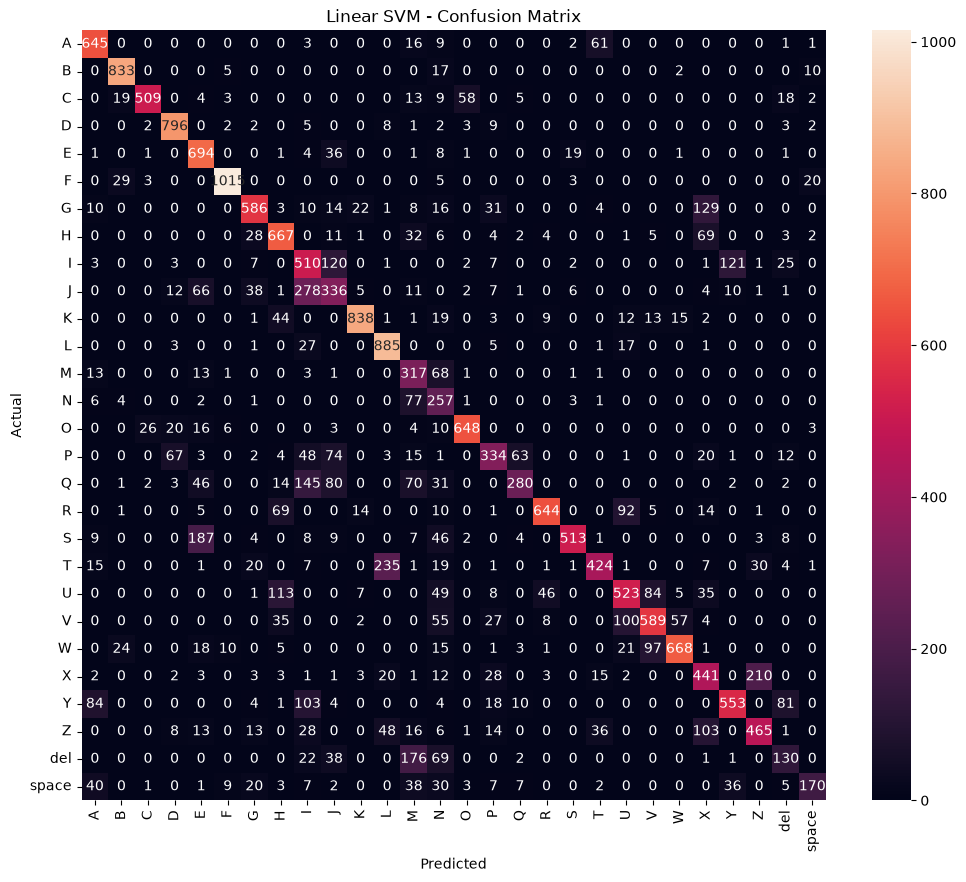

In [13]:
evaluate_model(
    "Linear SVM",
    y_val,
    y_val_pred,
    class_names
)



Wrist Centered Linear SVM
Accuracy : 98.48%

Classification Report:
              precision    recall  f1-score   support

           A       0.99      1.00      0.99       738
           B       0.99      1.00      1.00       867
           C       0.98      0.99      0.99       640
           D       0.99      0.99      0.99       835
           E       0.99      0.99      0.99       768
           F       1.00      1.00      1.00      1075
           G       0.98      1.00      0.99       834
           H       0.99      0.99      0.99       835
           I       0.98      0.97      0.98       803
           J       0.99      0.98      0.98       779
           K       0.98      0.99      0.98       958
           L       1.00      1.00      1.00       940
           M       0.89      0.95      0.92       419
           N       0.93      0.88      0.90       352
           O       0.99      0.99      0.99       736
           P       1.00      0.99      0.99       648
           

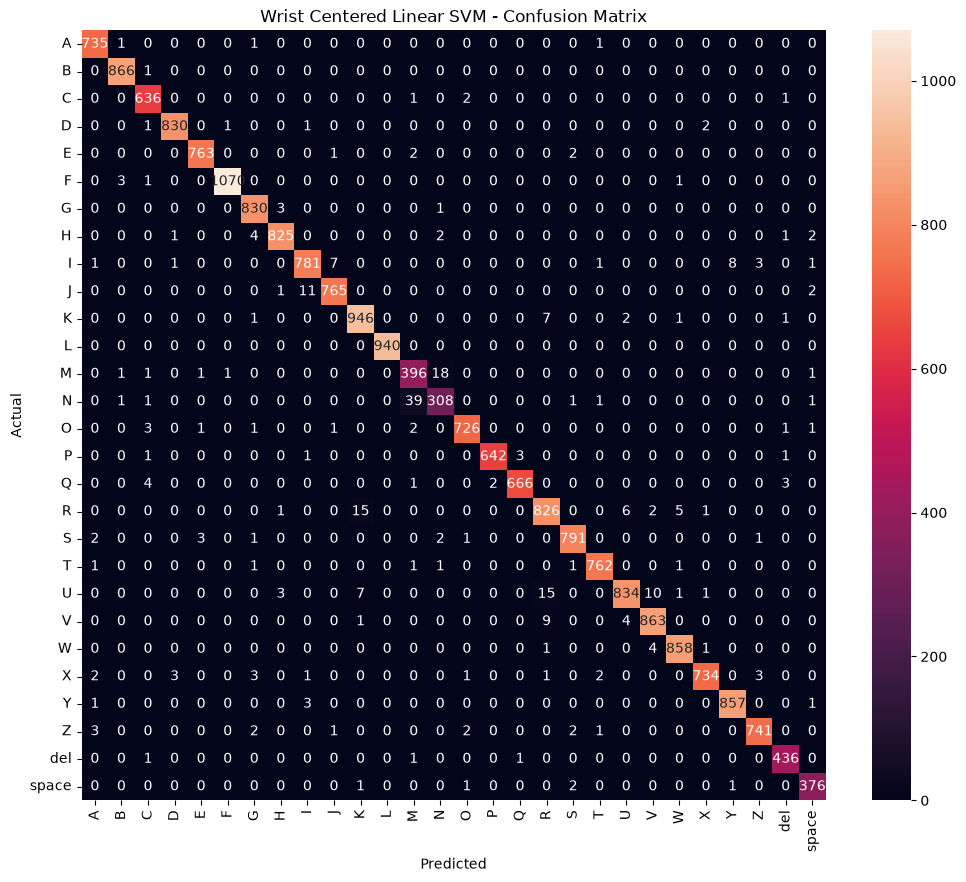

In [11]:
evaluate_model(
    "Wrist Centered Linear SVM",
    y_val,
    y_val_raw_pred,
    class_names
)



RBF SVM
Accuracy : 98.45%

Classification Report:
              precision    recall  f1-score   support

           A       0.97      0.99      0.98       738
           B       0.99      1.00      0.99       867
           C       0.99      0.99      0.99       640
           D       1.00      0.97      0.98       835
           E       1.00      0.99      1.00       768
           F       0.99      1.00      0.99      1075
           G       0.98      1.00      0.99       834
           H       0.99      0.99      0.99       835
           I       0.99      0.99      0.99       803
           J       0.99      0.99      0.99       779
           K       0.98      0.99      0.98       958
           L       1.00      1.00      1.00       940
           M       0.93      0.95      0.94       419
           N       0.96      0.91      0.94       352
           O       0.98      0.98      0.98       736
           P       1.00      0.99      1.00       648
           Q       1.00      

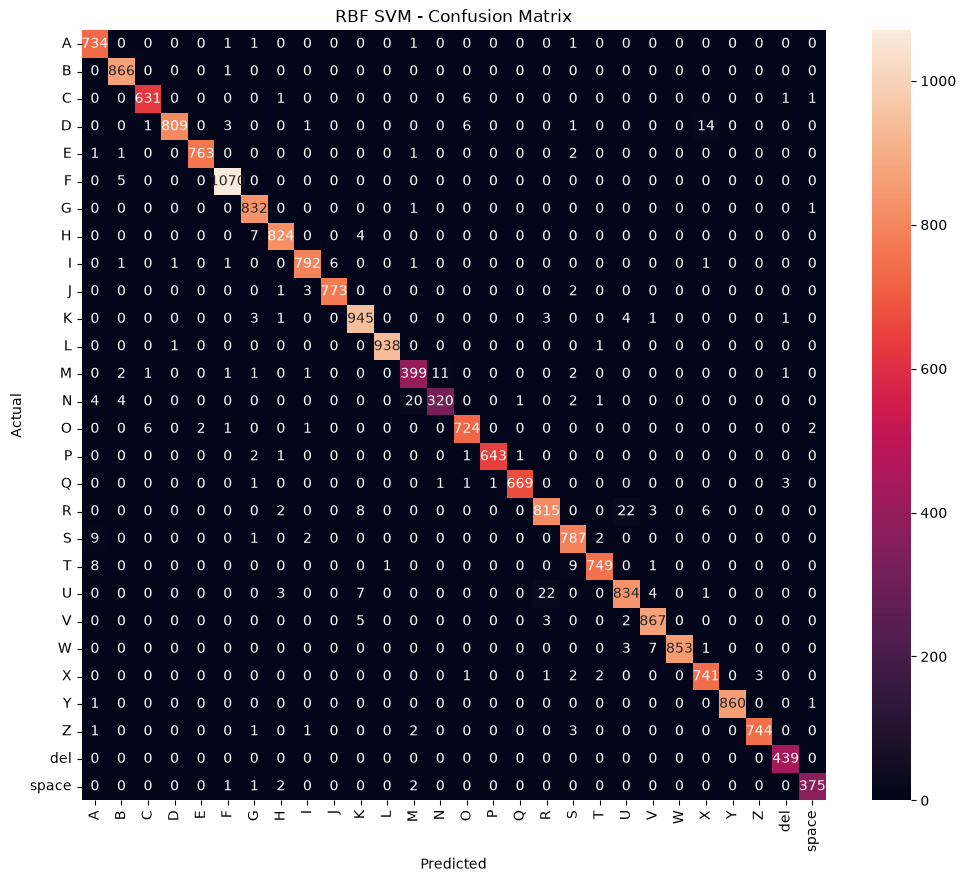

In [12]:
evaluate_model(
    "RBF SVM",
    y_val,
    y_val_rbf_pred,
    class_names
)